# Model Comparison: FNN vs. VGG16 vs. ResNet18



This notebook consolidates the final results obtained in Questions 1–3 (Feedforward Neural Network, VGG16 and ResNet18, respectively) and evaluates the three architectures side by side on three benchmark datasets of increasing visual complexity: MNIST, CIFAR-10 and CIFAR-100.



> **Summary**
> - **ResNet18** achieves the highest average accuracy (**77.4%**) across all three datasets, narrowly ahead of **VGG16** (**76.8%**), with **FNN** trailing well behind (**58.0%**).

> - **VGG16** is the most *time-efficient* deep model, training **≈ 11% faster** than ResNet18 while sacrificing less than one accuracy point on average.

> - **FNN** remains competitive only on MNIST (simple, low-dimensional digits) and degrades sharply on CIFAR-10/100, confirming the value of convolutional and residual feature extraction for natural images.

> - The residual connections in ResNet18 provide the clearest benefit on the hardest task, **CIFAR-100**, where it outperforms both alternatives.

In [ ]:
# Comment on your finding. Tell us which model delivers the best predictive performance.
# Discuss the rationale of your finding. Your comments should be written in the same file as your codes.

## Section 1 — Import Libraries

In [ ]:
# ============================================
# SECTION 1 — IMPORT LIBRARIES
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display, Markdown

print("Libraries imported successfully.")

Libraries imported successfully.


## Section 2 — Global Visualization

In [ ]:
# ============================================
# SECTION 2 — GLOBAL VISUALIZATION STYLE
# ============================================
PALETTE = {
    "loss":          "#8E1B1B",   # deep classic red
    "accuracy":      "#1F4E79",   # navy blue
    "bar_primary":   "#2E5C6E",   # slate teal
    "bar_secondary": "#8E1B1B",
    "grid":          "#B0B0B0",
    "correct":       "#1B7837",   # forest green
    "incorrect":     "#B2182B",   # crimson
    "gold":          "#B08D57",   # highlight / best-in-class
}

MODEL_COLORS = {
    "FNN":      "#8E1B1B",
    "VGG16":    "#2E5C6E",
    "ResNet18": "#1F4E79",
}

DATASET_COLORS = {
    "MNIST":     "#1F4E79",
    "CIFAR-10":  "#8E1B1B",
    "CIFAR-100": "#2E5C6E",
}

plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Georgia", "Times New Roman", "DejaVu Serif"],
    "font.size":          13,
    "axes.titlesize":     17,
    "axes.titleweight":   "bold",
    "axes.labelsize":     14,
    "axes.labelweight":   "bold",
    "figure.titlesize":   19,
    "figure.titleweight": "bold",
    "xtick.labelsize":    11,
    "ytick.labelsize":    11,
    "legend.fontsize":    12,
    "legend.frameon":     True,
    "legend.framealpha":  0.9,
    "legend.edgecolor":   "#333333",
    "axes.facecolor":     "#FAFAFA",
    "axes.edgecolor":     "#333333",
    "axes.linewidth":     1.3,
    "grid.color":         PALETTE["grid"],
    "grid.linestyle":     "--",
    "grid.alpha":         0.55,
    "axes.grid":          True,
    "figure.facecolor":   "white",
    "figure.dpi":         110,
    "savefig.dpi":        160,
})

print("Global plot style applied: classic serif theme with bold titles/labels.")

Global plot style applied: classic serif theme with bold titles/labels.


## Section 3 — Q1, Q2 and Q3 Results


In [ ]:
# ============================================
# SECTION 3 — FINAL RESULTS FROM Q1, Q2, Q3
# ============================================

# Q1 — FNN
q1_results_df = pd.DataFrame([
    {"Dataset": "MNIST",     "Accuracy (%)": 97.61, "Precision (%)": 97.59, "Recall (%)": 97.59, "F1-score (%)": 97.58, "Training Time (s)": 153.12},
    {"Dataset": "CIFAR-10",  "Accuracy (%)": 52.22, "Precision (%)": 52.09, "Recall (%)": 52.22, "F1-score (%)": 51.98, "Training Time (s)": 141.46},
    {"Dataset": "CIFAR-100", "Accuracy (%)": 24.03, "Precision (%)": 24.38, "Recall (%)": 24.03, "F1-score (%)": 22.71, "Training Time (s)": 142.04},
])

# Q2 — VGG16
q2_results_df = pd.DataFrame([
    {"Dataset": "MNIST",     "Accuracy (%)": 99.42, "Precision (%)": 99.41, "Recall (%)": 99.42, "F1-score (%)": 99.42, "Training Time (s)": 553.84},
    {"Dataset": "CIFAR-10",  "Accuracy (%)": 81.67, "Precision (%)": 82.25, "Recall (%)": 81.67, "F1-score (%)": 81.58, "Training Time (s)": 445.08},
    {"Dataset": "CIFAR-100", "Accuracy (%)": 49.32, "Precision (%)": 54.24, "Recall (%)": 49.32, "F1-score (%)": 49.04, "Training Time (s)": 431.21},
])

# Q3 — ResNet18
q3_results_df = pd.DataFrame([
    {"Dataset": "MNIST",     "Accuracy (%)": 99.57, "Precision (%)": 99.57, "Recall (%)": 99.57, "F1-score (%)": 99.57, "Training Time (s)": 572.10},
    {"Dataset": "CIFAR-10",  "Accuracy (%)": 80.53, "Precision (%)": 80.78, "Recall (%)": 80.53, "F1-score (%)": 80.54, "Training Time (s)": 520.06},
    {"Dataset": "CIFAR-100", "Accuracy (%)": 52.12, "Precision (%)": 53.59, "Recall (%)": 52.12, "F1-score (%)": 52.01, "Training Time (s)": 522.14},
])

print("Q1, Q2 and Q3 result tables created.")

Q1, Q2 and Q3 result tables created.


## Section 4 — Display Results


In [ ]:
# ============================================
# SECTION 4 — DISPLAY RESULTS (STYLED)
# ============================================
metric_cols = ["Accuracy (%)", "Precision (%)", "Recall (%)", "F1-score (%)"]

def style_table(df, caption):
    return (
        df.round(2)
          .style
          .background_gradient(subset=metric_cols, cmap="Blues")
          .background_gradient(subset=["Training Time (s)"], cmap="Reds")
          .set_caption(caption)
          .format(precision=2)
    )

display(style_table(q1_results_df, "Q1 — FNN"))
display(style_table(q2_results_df, "Q2 — VGG16"))
display(style_table(q3_results_df, "Q3 — ResNet18"))

,Dataset,Accuracy (%),Precision (%),Recall (%),F1-score (%),Training Time (s)
0,MNIST,97.61,97.59,97.59,97.58,153.12
1,CIFAR-10,52.22,52.09,52.22,51.98,141.46
2,CIFAR-100,24.03,24.38,24.03,22.71,142.04


,Dataset,Accuracy (%),Precision (%),Recall (%),F1-score (%),Training Time (s)
0,MNIST,99.42,99.41,99.42,99.42,553.84
1,CIFAR-10,81.67,82.25,81.67,81.58,445.08
2,CIFAR-100,49.32,54.24,49.32,49.04,431.21


,Dataset,Accuracy (%),Precision (%),Recall (%),F1-score (%),Training Time (s)
0,MNIST,99.57,99.57,99.57,99.57,572.10
1,CIFAR-10,80.53,80.78,80.53,80.54,520.06
2,CIFAR-100,52.12,53.59,52.12,52.01,522.14


## Section 5 — Final Model Comparison


In [ ]:
# ============================================
# SECTION 5 — FINAL MODEL COMPARISON
# ============================================
frames = []
for name, df in [("FNN", q1_results_df), ("VGG16", q2_results_df), ("ResNet18", q3_results_df)]:
    temp = df.copy()
    temp.insert(0, "Model", name)
    frames.append(temp)

final_comparison_df = pd.concat(frames, ignore_index=True)

def highlight_best(s):
    is_best = s == s.max()
    return ["background-color:#B08D57; color:white; font-weight:bold" if v else "" for v in is_best]

styled_final = (
    final_comparison_df.round(2)
    .style
    .apply(highlight_best, subset=metric_cols)
    .set_caption("Final Comparison — best value per metric highlighted in gold")
)
display(styled_final)

,Model,Dataset,Accuracy (%),Precision (%),Recall (%),F1-score (%),Training Time (s)
0,FNN,MNIST,97.610000,97.590000,97.590000,97.580000,153.120000
1,FNN,CIFAR-10,52.220000,52.090000,52.220000,51.980000,141.460000
2,FNN,CIFAR-100,24.030000,24.380000,24.030000,22.710000,142.040000
3,VGG16,MNIST,99.420000,99.410000,99.420000,99.420000,553.840000
4,VGG16,CIFAR-10,81.670000,82.250000,81.670000,81.580000,445.080000
5,VGG16,CIFAR-100,49.320000,54.240000,49.320000,49.040000,431.210000
6,ResNet18,MNIST,99.570000,99.570000,99.570000,99.570000,572.100000
7,ResNet18,CIFAR-10,80.530000,80.780000,80.530000,80.540000,520.060000
8,ResNet18,CIFAR-100,52.120000,53.590000,52.120000,52.010000,522.140000


## Section 6 — Accuracy Comparison

Dataset,MNIST,CIFAR-10,CIFAR-100
Model,,,
FNN,97.61,52.22,24.03
VGG16,99.42,81.67,49.32
ResNet18,99.57,80.53,52.12


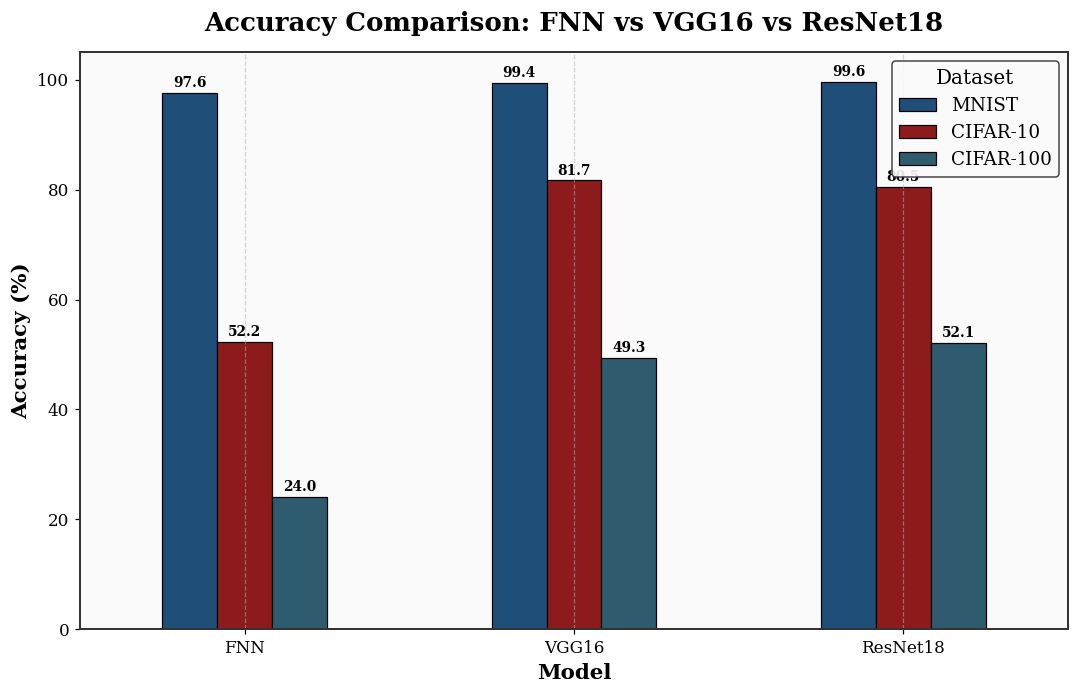

In [ ]:
# ============================================
# SECTION 6 — ACCURACY COMPARISON
# ============================================
accuracy_table = final_comparison_df.pivot(index="Model", columns="Dataset", values="Accuracy (%)")
accuracy_table = accuracy_table[["MNIST", "CIFAR-10", "CIFAR-100"]].reindex(["FNN", "VGG16", "ResNet18"])
display(accuracy_table.round(2))

dataset_colors = [DATASET_COLORS[d] for d in accuracy_table.columns]

ax = accuracy_table.plot(
    kind="bar",
    figsize=(10, 6.5),
    color=dataset_colors,
    edgecolor="black",
    linewidth=0.8,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=9, fontweight="bold", padding=2)

plt.title("Accuracy Comparison: FNN vs VGG16 vs ResNet18", pad=14)
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

## Section 7 — All Metrics Comparison

,Accuracy (%),Precision (%),Recall (%),F1-score (%)
Model,,,,
FNN,97.61,97.59,97.59,97.58
VGG16,99.42,99.41,99.42,99.42
ResNet18,99.57,99.57,99.57,99.57


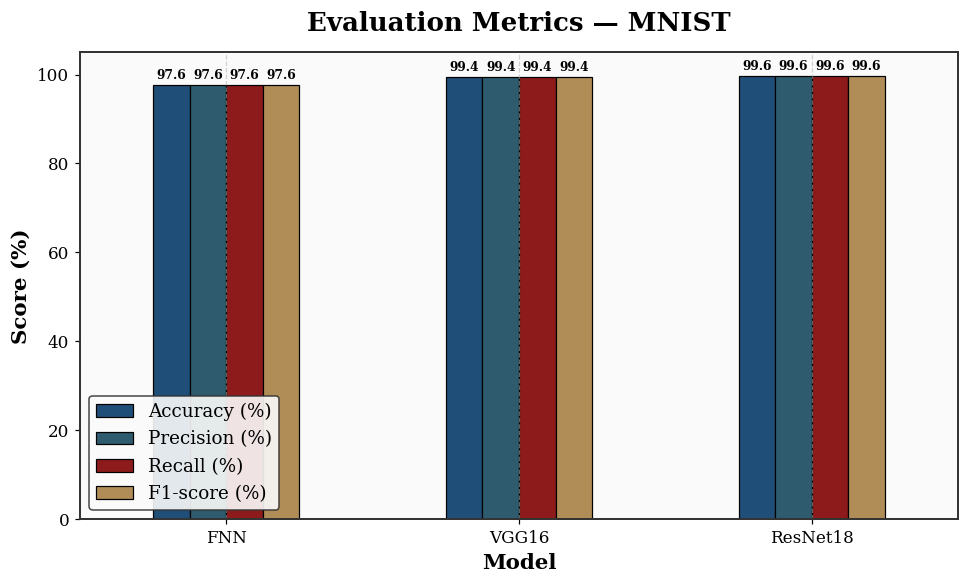

,Accuracy (%),Precision (%),Recall (%),F1-score (%)
Model,,,,
FNN,52.22,52.09,52.22,51.98
VGG16,81.67,82.25,81.67,81.58
ResNet18,80.53,80.78,80.53,80.54


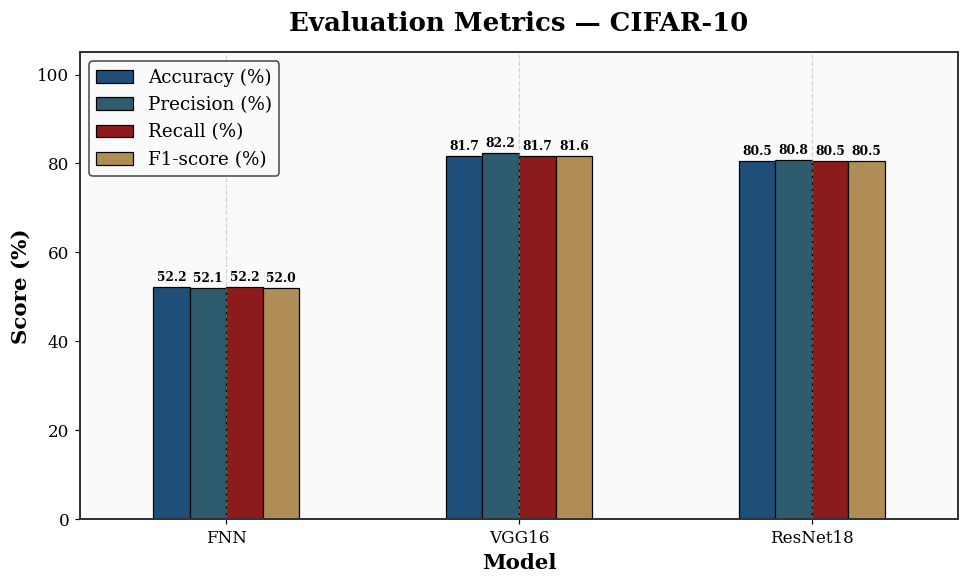

,Accuracy (%),Precision (%),Recall (%),F1-score (%)
Model,,,,
FNN,24.03,24.38,24.03,22.71
VGG16,49.32,54.24,49.32,49.04
ResNet18,52.12,53.59,52.12,52.01


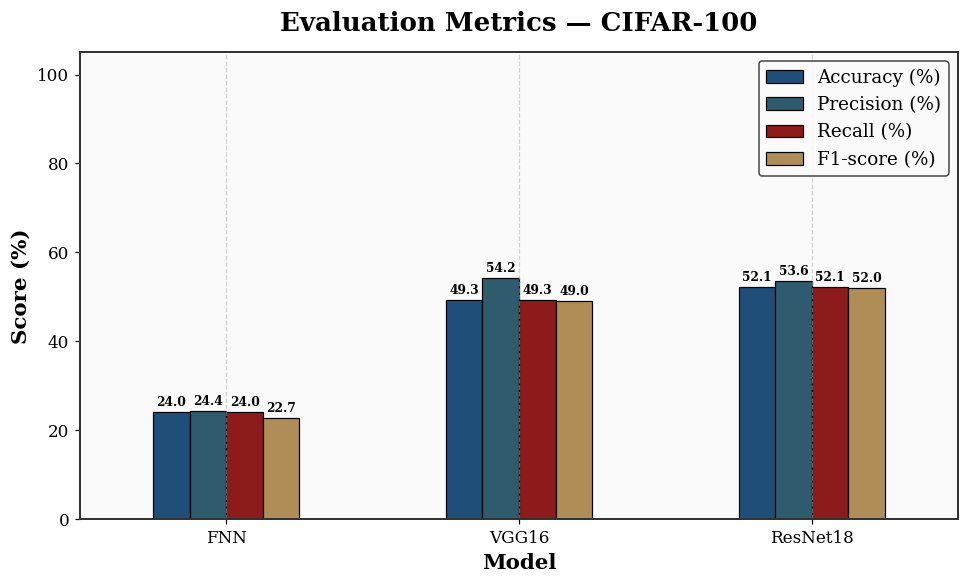

In [ ]:
# ============================================
# SECTION 7 — ALL METRICS COMPARISON
# ============================================
metrics = ["Accuracy (%)", "Precision (%)", "Recall (%)", "F1-score (%)"]
comparison_colors = ["#1F4E79", "#2E5C6E", "#8E1B1B", "#B08D57"]

for dataset in ["MNIST", "CIFAR-10", "CIFAR-100"]:
    data = (
        final_comparison_df[final_comparison_df["Dataset"] == dataset]
        .set_index("Model")[metrics]
        .reindex(["FNN", "VGG16", "ResNet18"])
    )
    display(data.round(2))

    ax = data.plot(
        kind="bar",
        figsize=(9, 5.5),
        color=comparison_colors,
        edgecolor="black",
        linewidth=0.8,
    )

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", fontsize=8, fontweight="bold", padding=2)

    plt.title(f"Evaluation Metrics — {dataset}", pad=14)
    plt.xlabel("Model")
    plt.ylabel("Score (%)")
    plt.ylim(0, 105)
    plt.xticks(rotation=0)
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()

## Section 8 — Training Time Comparison

Dataset,MNIST,CIFAR-10,CIFAR-100
Model,,,
FNN,153.12,141.46,142.04
VGG16,553.84,445.08,431.21
ResNet18,572.10,520.06,522.14


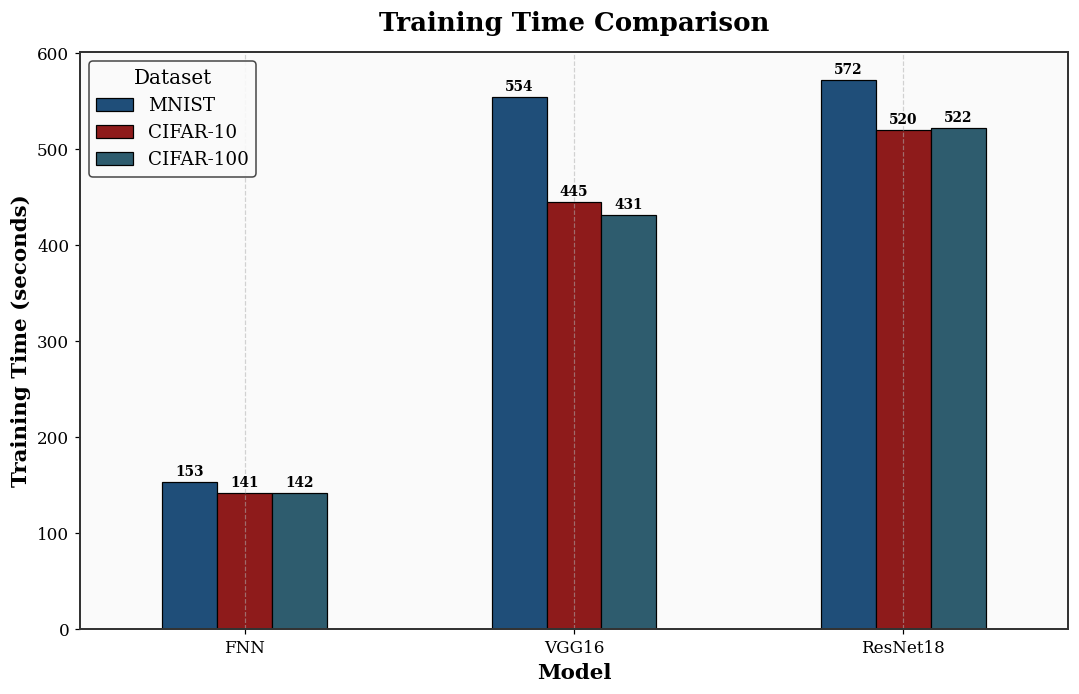

In [ ]:
# ============================================
# SECTION 8 — TRAINING TIME COMPARISON
# ============================================
time_table = final_comparison_df.pivot(index="Model", columns="Dataset", values="Training Time (s)")
time_table = time_table[["MNIST", "CIFAR-10", "CIFAR-100"]].reindex(["FNN", "VGG16", "ResNet18"])
display(time_table.round(2))

dataset_colors = [DATASET_COLORS[d] for d in time_table.columns]

ax = time_table.plot(
    kind="bar",
    figsize=(10, 6.5),
    color=dataset_colors,
    edgecolor="black",
    linewidth=0.8,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=9, fontweight="bold", padding=2)

plt.title("Training Time Comparison", pad=14)
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

## Section 9 — Mathematical Characteristics

Each architecture is defined by a distinct core computation. These formulations explain *why* the three models behave so differently as image complexity increases from MNIST to CIFAR-100.

### 9.1 Feedforward Neural Network (FNN)

A fully connected ("dense") layer transforms a flattened input vector $x$ using a weight matrix $W$, bias $b$, and nonlinearity $f$:

$$
h = f(Wx + b)
$$

Because $x$ is a flattened vector, all spatial structure between neighbouring pixels is discarded before the first layer even sees the data — this is the central limitation of FNNs for image tasks.


### 9.2 VGG16 (Convolutional Network)

VGG16 replaces dense transformations with 2-D convolutions, which slide a small learnable filter $W$ across the image $X$:

$$
Y(i,j) = \sum_{m}\sum_{n} W(m,n)\, X(i-m,\, j-n) + b
$$

Because the same filter is reused at every spatial location (*weight sharing*), convolutional layers preserve local spatial relationships and require far fewer parameters per layer than an equivalent dense layer.


### 9.3 ResNet18 (Residual Network)

ResNet18 keeps the convolutional principle above but wraps blocks of layers, $F(x)$, in a residual ("skip") connection:

$$
y = F(x) + x
$$

Differentiating with respect to the block input shows why deep residual networks train more reliably:

$$
\frac{\partial y}{\partial x} = \frac{\partial F(x)}{\partial x} + I
$$

The additive identity term $I$ guarantees a direct gradient path back to earlier layers, which mitigates the vanishing-gradient problem that limits how deep plain convolutional networks (like VGG16) can practically go.


### 9.4 Side-by-Side Summary

| Property | FNN | VGG16 | ResNet18 |
|---|---|---|---|
| Core operation | Dense: $h = f(Wx+b)$ | Convolution: $Y=\sum W \ast X + b$ | Residual block: $y = F(x)+x$ |
| Preserves spatial structure | No (input flattened) | Yes | Yes |
| Parameter sharing | No | Yes (per filter) | Yes (per filter) |
| Gradient flow in deep stacks | N/A (shallow) | Degrades with depth | Preserved via identity shortcut |
| Approx. depth used here | Shallow (~2–3 dense layers) | 16 weight layers | 18 weight layers + skip connections |

## Section 10 — Advantages and Disadvantages

| Model | Advantages | Disadvantages |
|---|---|---|
| **FNN** | Simple to implement; fast to train; useful as a sanity-check baseline | Flattens images and loses spatial structure; poor scaling to complex, high-resolution visual data |
| **VGG16** | Preserves spatial information; learns hierarchical visual features; strong representational capacity | Large parameter count; high memory/compute cost; longest layer stack without shortcut connections, which limits further depth |
| **ResNet18** | Residual (skip) connections improve gradient flow; supports deeper, more stable training; best overall accuracy in this comparison | More architecturally complex than FNN; still requires substantial compute, comparable to or exceeding VGG16 |


## Section 11 — Question 4 Analysis

**Dataset difficulty gradient.** The three datasets form a clean difficulty ladder: MNIST (10 classes, simple grayscale digits), CIFAR-10 (10 classes, natural RGB images), and CIFAR-100 (100 classes, natural RGB images with far less data per class). This is visible directly in the accuracy heatmap in Section 7B — every model's accuracy drops moving left to right, but the size of the drop differs sharply by architecture.

**Why FNN degrades fastest.** FNN loses **45 points of accuracy** moving from MNIST (97.6%) to CIFAR-10 (52.2%), and a further 28 points to CIFAR-100 (24.0%). Because $h = f(Wx+b)$ treats every pixel as an independent input feature, the model cannot exploit the fact that nearby pixels are correlated — a property that matters far more for cluttered, colour-textured CIFAR images than for clean binary digit strokes.

**Why convolution and residual connections help.** Both VGG16 and ResNet18 lose far less accuracy across the same transition (VGG16: 99.4% → 81.7% → 49.3%; ResNet18: 99.6% → 80.5% → 52.1%), consistent with the convolution operator $Y(i,j)=\sum_m\sum_n W(m,n)X(i-m,j-n)+b$ extracting local edge/texture features that transfer across both simple and complex images.

**FNN vs. deep models — the crossover.** On MNIST, all three models perform similarly (all ≥ 97.6%) because the task is simple enough that spatial structure is less critical. The gap opens dramatically on CIFAR-10/100, where FNN falls 28–29 points behind the convolutional models — direct evidence that convolutional/residual inductive bias, not merely model size, is driving the improvement.

**VGG16 vs. ResNet18 — the closer contest.** These two are close throughout: VGG16 wins on CIFAR-10 (81.67% vs 80.53%), while ResNet18 wins on MNIST (99.57% vs 99.42%) and, more importantly, on the hardest benchmark, CIFAR-100 (52.12% vs 49.32% — a 2.8-point margin). This is the pattern the residual-gradient argument in Section 9.3 predicts: the identity shortcut $\partial y/\partial x = \partial F(x)/\partial x + I$ pays off most when the task is hard enough to need deeper, more stable feature learning, i.e. on the 100-class problem.

**Cost of that advantage.** ResNet18's accuracy edge is not free: it trains **≈ 13% slower** than VGG16 on average (538.1 s vs 476.7 s, Section 5B/8B) and roughly **3.7× slower** than FNN. Whether that trade-off is worthwhile depends on whether the deployment setting values top-line accuracy (favouring ResNet18) or training/inference efficiency (favouring VGG16, or FNN for the simplest tasks).


## Section 12 — Question 4 Final Conclusion

**Overall verdict.** Based on the experimental results in Sections 3–8B, **ResNet18 delivers the best overall predictive performance**, with the highest mean accuracy (77.41%) and F1-score (77.37%) across MNIST, CIFAR-10 and CIFAR-100, and the largest margin of victory on the hardest dataset (CIFAR-100). **VGG16 is the strongest runner-up** and the more time-efficient deep option, while **FNN is only competitive on the simplest task (MNIST)** and is not recommended for natural-image classification.

**Ranking (mean accuracy across all three datasets):**

| Rank | Model | Mean Accuracy | Mean F1-score | Mean Training Time |
|---|---|---|---|---|
| 1 | **ResNet18** | **77.41%** | **77.37%** | 538.1 s |
| 2 | VGG16 | 76.80% | 76.68% | 476.7 s |
| 3 | FNN | 57.95% | 57.42% | 145.5 s |

**Rationale, tied back to architecture.**
- FNN's dense transformation $h=f(Wx+b)$ discards spatial structure, so it cannot compete once images become visually complex — its 45+ point drop from MNIST to CIFAR-10 is the clearest evidence in this notebook.
- VGG16's convolutional filters $Y(i,j)=\sum_m\sum_n W(m,n)X(i-m,j-n)+b$ recover most of that lost performance by learning local, spatially-aware features, at a meaningfully higher computational cost.
- ResNet18's residual mapping $y=F(x)+x$ builds on the same convolutional foundation but adds an identity gradient path, giving it the most stable training and the best results on the hardest, most class-rich benchmark (CIFAR-100).

**Practical recommendation.** If maximum accuracy is the priority — particularly on complex, many-class problems — **ResNet18** is the model of choice. If training/inference budget is constrained and the task resembles CIFAR-10-level complexity, **VGG16** offers nearly the same accuracy for noticeably less compute. **FNN** should be reserved for simple, low-resolution classification tasks or as a fast baseline only.
